In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np 

data = pd.read_csv("data/train(1).csv")

In [3]:
from sklearn.model_selection import train_test_split
X = data.drop(columns=['date','price'])
y = data['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model on Tabular Data

In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = round(r2_score(y_test, y_pred),2)
    rmse =  round(root_mean_squared_error(y_test, y_pred),2)
    mae =  round(mean_absolute_error(y_test, y_pred),2)
    mape =  round(mean_absolute_percentage_error(y_test, y_pred),2)
    results[name] = {
        "R2 Score": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

results_df = pd.DataFrame(results).T
display(results_df)

,R2 Score,RMSE,MAE,MAPE
Linear Regression,0.71,191570.99,125410.36,25.84
Ridge Regression,0.71,191613.70,125386.29,25.83
Lasso Regression,0.71,191571.79,125409.27,25.84
Decision Tree,0.73,182398.56,102293.93,18.68
Random Forest,0.86,131819.08,72196.87,13.19
Gradient Boosting,0.86,130178.82,78291.58,14.73


Hyperparameter Tuning of Gradient Boosting Algorithm

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    gb,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=2 
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best RMSE:", -grid_search.best_score_)

best_gb = grid_search.best_estimator_
y_pred = best_gb.predict(X_test)
r2 = round(r2_score(y_test, y_pred), 2)
rmse = round(root_mean_squared_error(y_test, y_pred), 2)
mae = round(mean_absolute_error(y_test, y_pred), 2)
mape = round(np.mean(np.abs((y_test - y_pred) / y_test)) * 100, 2)

print(f"Gradient Boosting (Tuned): R2={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}%")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   1.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   1.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   1.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   2.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   2.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   2.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1.0; total time=   2.7

In [6]:
gb_best = GradientBoostingRegressor(
    learning_rate=0.1,
    max_depth=4,
    n_estimators=300,
    subsample=0.8,
    random_state=42
)
gb_best.fit(X_train, y_train)
y_pred = gb_best.predict(X_test)

r2 = round(r2_score(y_test, y_pred), 2)
rmse = round(root_mean_squared_error(y_test, y_pred), 2)
mae = round(mean_absolute_error(y_test, y_pred), 2)
mape = round(np.mean(np.abs((y_test - y_pred) / y_test)) * 100, 2)

print(f"Gradient Boosting (Best Params): R2={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}%")

Gradient Boosting (Best Params): R2=0.8900, RMSE=118641.97, MAE=69378.72, MAPE=12.98%


Using Tabular Data + Features Extracted from Images

In [9]:
import pandas as pd
import numpy as np

data = pd.read_csv("data/train(1).csv")
image_features = pd.read_csv("image_features.csv")
cnn_features = pd.read_csv("cnn_image_features_pytorch.csv")

image_features['image_id'] = image_features['image'].str.extract(r'(\d+)').astype(int)
cnn_features['image_id'] = cnn_features['image'].str.extract(r'(\d+)').astype(int)

cnn_features_expanded = pd.DataFrame(cnn_features['features'].apply(eval).to_list())
cnn_features_expanded.columns = [f'cnn_feat_{i}' for i in range(cnn_features_expanded.shape[1])]
cnn_features = pd.concat([cnn_features.drop(columns=['features']), cnn_features_expanded], axis=1)

data = data.merge(image_features, left_on="id", right_on="image_id", how="left")
data = data.merge(cnn_features.drop(columns=['image']), left_on="id", right_on="image_id", how="left")
data.drop(columns=['image_id_x', 'image_id_y', 'image'], inplace=True, errors='ignore')

data['green_area_ratio'] = data['green_area_ratio'].round(3)
data['concrete_area_ratio'] = data['concrete_area_ratio'].round(3)

data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,cnn_feat_502,cnn_feat_503,cnn_feat_504,cnn_feat_505,cnn_feat_506,cnn_feat_507,cnn_feat_508,cnn_feat_509,cnn_feat_510,cnn_feat_511
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,0.585155,0.898585,0.177405,0.747886,0.008753,1.223054,1.220472,1.422659,0.575849,0.116725
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,0.268944,0.556181,0.077563,0.748939,0.000951,0.431030,0.321496,2.477471,0.473559,0.292709
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,1.008122,1.597846,0.297941,2.169188,0.015850,1.505876,0.067908,2.978111,0.302907,0.472202
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,0.017169,2.483743,0.387429,1.411541,0.042993,1.606709,0.107960,1.043961,0.060660,0.332112
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,0.157683,2.799114,0.030954,1.027936,0.256541,1.317838,0.268137,1.655477,0.313592,0.185303


In [10]:
from sklearn.decomposition import PCA

cnn_feature_cols = [col for col in data.columns if col.startswith('cnn_feat_')]

pca = PCA(n_components=5, random_state=42)
cnn_pca = pca.fit_transform(data[cnn_feature_cols].fillna(0))

for i in range(cnn_pca.shape[1]):
    data[f'cnn_pca_{i}'] = cnn_pca[:, i]

data.drop(columns=cnn_feature_cols, inplace=True)

data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,long,sqft_living15,sqft_lot15,green_area_ratio,concrete_area_ratio,cnn_pca_0,cnn_pca_1,cnn_pca_2,cnn_pca_3,cnn_pca_4
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,-122.187,1660,9240,0.527,0.405,0.627109,-1.904551,-4.460408,0.137004,0.260635
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,-122.187,1720,3605,0.547,0.438,2.468790,2.652721,-0.824107,1.253816,-0.811856
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,-122.313,1870,7455,0.386,0.598,-6.687800,-5.261919,-1.599833,1.493313,0.826560
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,-122.073,1240,750,0.513,0.416,-11.923745,-6.974027,-1.994538,1.728440,-1.167756
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,-122.074,1590,8071,0.493,0.395,-12.754516,-6.291933,1.074035,0.907277,-3.535286


In [8]:
X = data.drop(columns=['date', 'price'])
y = data['price']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gb_with_img = GradientBoostingRegressor(
    learning_rate=0.1,
    max_depth=4,
    n_estimators=300,
    subsample=0.8,
    random_state=42
)
gb_with_img.fit(X_train, y_train)
y_pred = gb_with_img.predict(X_test)

r2 = round(r2_score(y_test, y_pred), 2)
rmse = round(root_mean_squared_error(y_test, y_pred), 2)
mae = round(mean_absolute_error(y_test, y_pred), 2)
mape = round(np.mean(np.abs((y_test - y_pred) / y_test)) * 100, 2)

print(f"Gradient Boosting (With Image Features): R2={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}%")

Gradient Boosting (With Image Features): R2=0.8900, RMSE=118641.97, MAE=69378.72, MAPE=12.98%


Number of tabular features: 18
Total features in X_train: 19
Using device: cuda
Found 12967 valid images out of 12967 samples
Found 3242 valid images out of 3242 samples

Starting training...
Epoch 1/10 - Train RMSE: 330614.58, Val RMSE: 239257.71, Val R2: 0.5431
Epoch 2/10 - Train RMSE: 228185.41, Val RMSE: 317204.79, Val R2: 0.1976
Epoch 3/10 - Train RMSE: 205920.72, Val RMSE: 188136.65, Val R2: 0.7177
Epoch 4/10 - Train RMSE: 201647.43, Val RMSE: 184000.96, Val R2: 0.7299
Epoch 5/10 - Train RMSE: 196723.02, Val RMSE: 184751.02, Val R2: 0.7278
Epoch 6/10 - Train RMSE: 193067.17, Val RMSE: 184329.60, Val R2: 0.7289
Epoch 7/10 - Train RMSE: 188250.82, Val RMSE: 177430.58, Val R2: 0.7489
Epoch 8/10 - Train RMSE: 186562.98, Val RMSE: 170022.59, Val R2: 0.7693
Epoch 9/10 - Train RMSE: 181988.10, Val RMSE: 174182.75, Val R2: 0.7579
Epoch 10/10 - Train RMSE: 180765.79, Val RMSE: 257435.08, Val R2: 0.4713

Training complete!
Model saved to 'price_prediction_cnn.pth'

Generating Grad-CAM visu

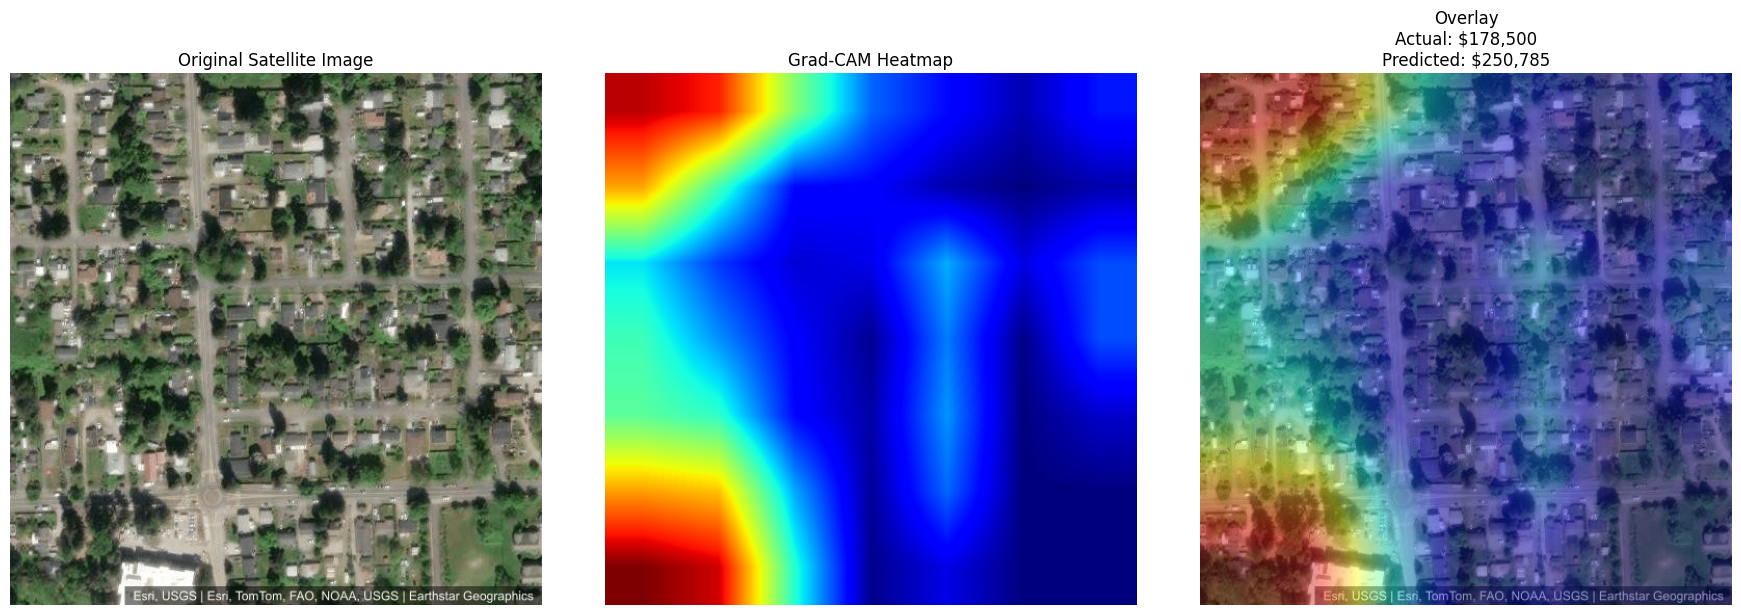

High-importance regions: 26199 pixels

Analyzing Property ID: 2397100705


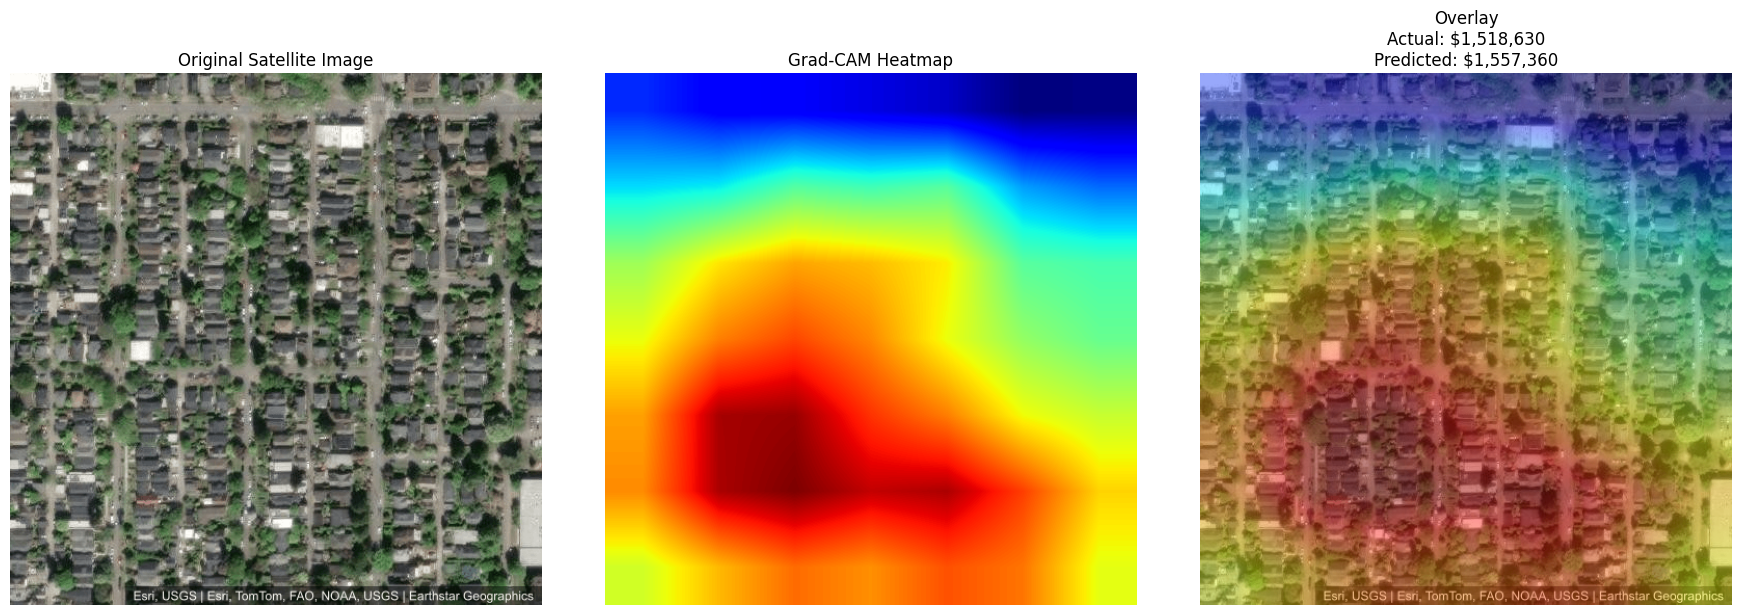

High-importance regions: 26215 pixels

Analyzing Property ID: 4051110240


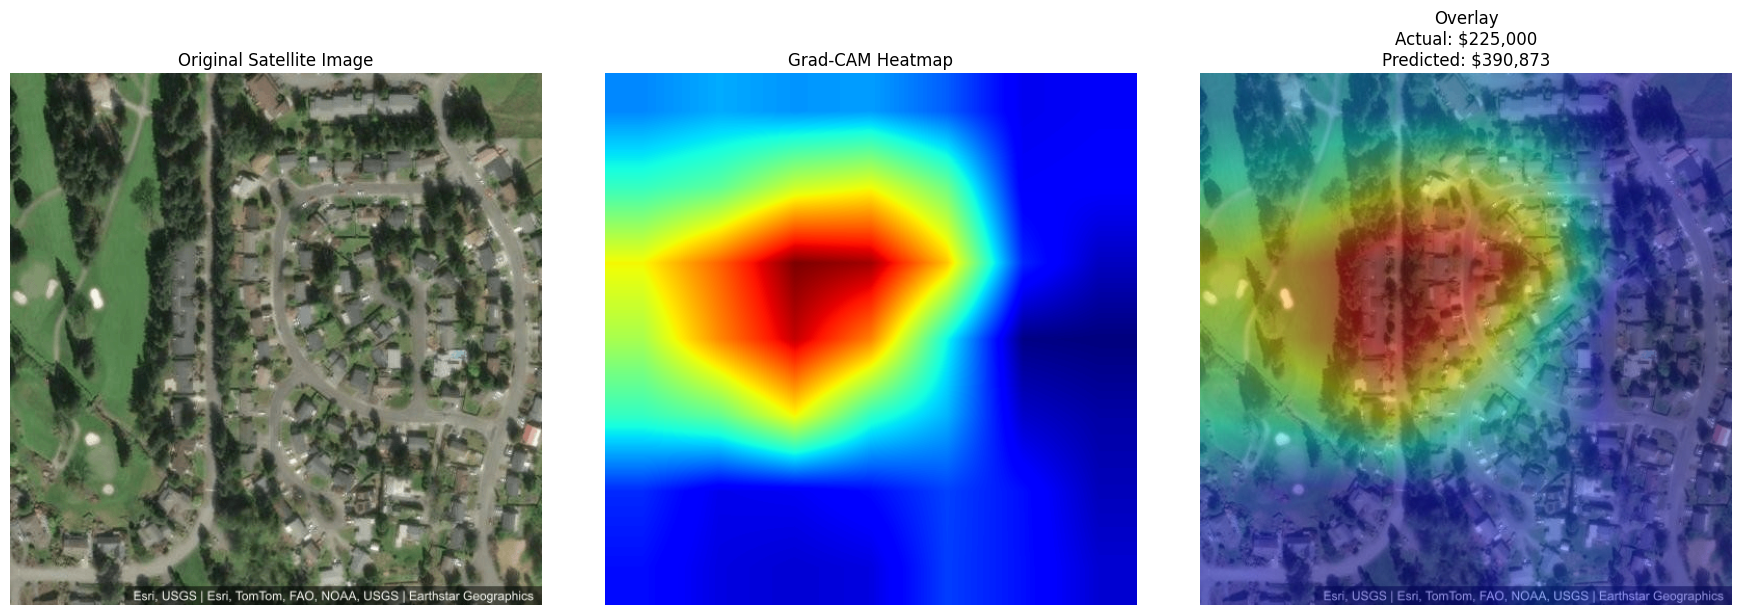

High-importance regions: 26215 pixels

Analyzing Property ID: 259100110


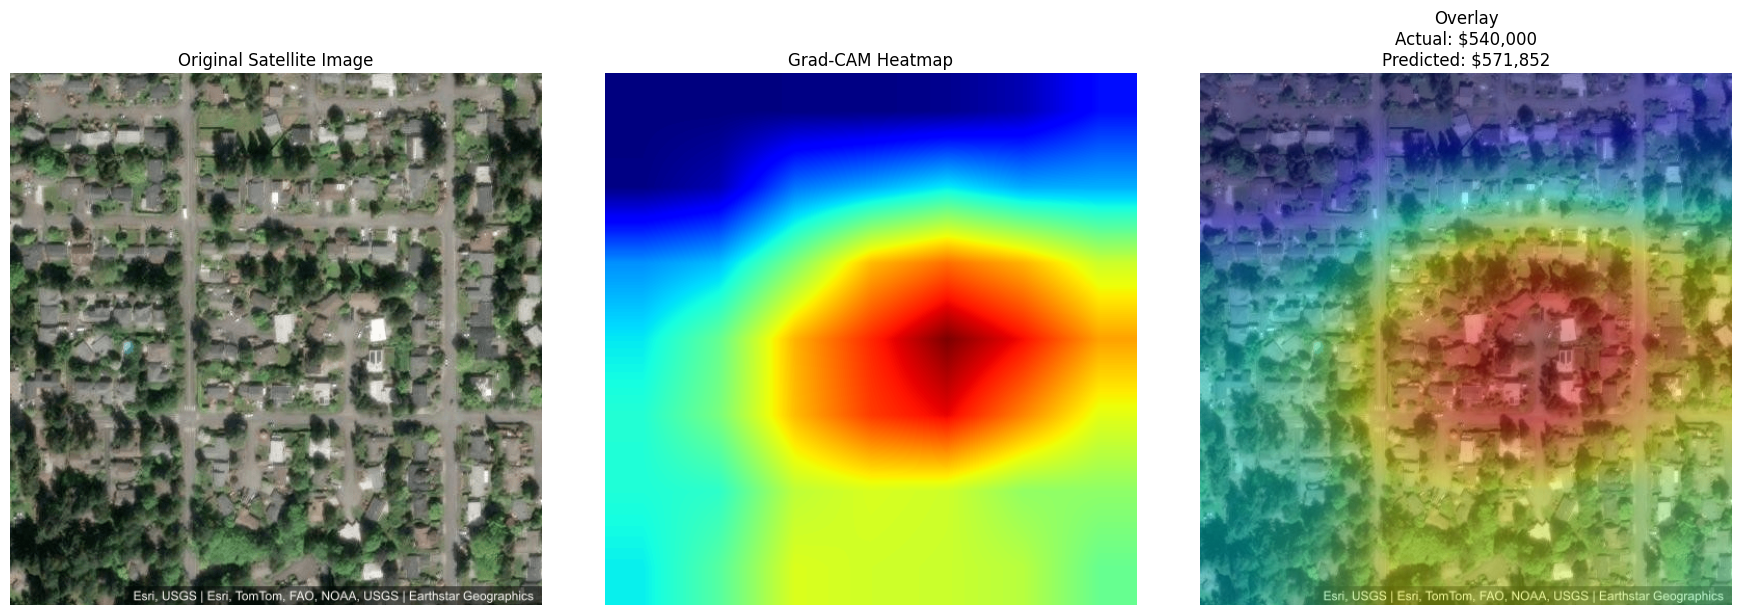

High-importance regions: 26215 pixels

Analyzing Property ID: 2658000215


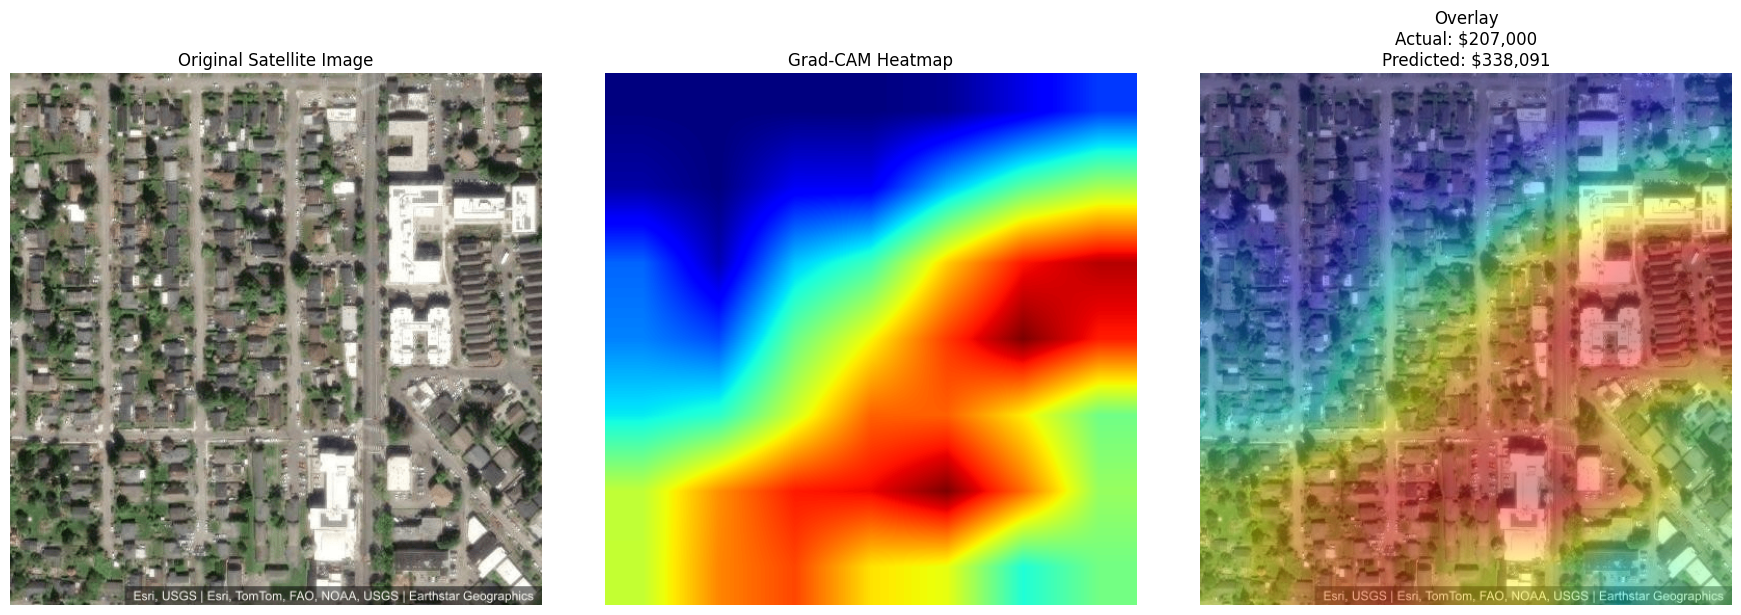

High-importance regions: 26215 pixels


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import os

class PropertyDataset(Dataset):
    def __init__(self, X, y, image_dir, tabular_cols, transform=None):
        self.X = X.reset_index(drop=True)
        self.y = y.reset_index(drop=True)
        self.image_dir = image_dir
        self.tabular_cols = tabular_cols
        self.transform = transform
        self.valid_indices = []

        for i in range(len(self.X)):
            property_id = int(self.X.iloc[i]['id'])
            image_path = os.path.join(self.image_dir, f"{property_id}.png")
            if os.path.exists(image_path):
                self.valid_indices.append(i)
        
        print(f"Found {len(self.valid_indices)} valid images out of {len(self.X)} samples")
    
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        row = self.X.iloc[actual_idx]
        property_id = int(row['id'])
        image_path = os.path.join(self.image_dir, f"{property_id}.png")

        img = Image.open(image_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
 
        tabular = torch.FloatTensor(row[self.tabular_cols].values)

        price = torch.FloatTensor([self.y.iloc[actual_idx]])
        
        return img, tabular, price

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
    
    def generate_cam(self, input_image, tabular_features, target_output=None):
        self.model.eval()
        output = self.model(input_image, tabular_features)
        
        if target_output is None:
            target_output = output
        
        self.model.zero_grad()
        target_output.backward()

        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = torch.relu(cam)
 
        cam = cam - cam.min()
        cam = cam / cam.max()
        
        return cam.squeeze().cpu().numpy()


class PricePredictionCNN(nn.Module):
    def __init__(self, num_tabular_features):
        super(PricePredictionCNN, self).__init__()

        self.cnn = models.resnet18(pretrained=True)
        num_features = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity() 

        self.fc_combined = nn.Sequential(
            nn.Linear(num_features + num_tabular_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )
    
    def forward(self, image, tabular_features):
        cnn_features = self.cnn(image)
        combined = torch.cat([cnn_features, tabular_features], dim=1)
        price = self.fc_combined(combined)
        return price

tabular_cols = [col for col in X_train.columns 
                if not col.startswith('cnn_pca_') 
                and col not in ['green_area_ratio', 'concrete_area_ratio', 'id']]

num_tabular_features = len(tabular_cols)
print(f"Number of tabular features: {num_tabular_features}")
print(f"Total features in X_train: {X_train.shape[1]}")

model = PricePredictionCNN(num_tabular_features)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = model.to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

train_dataset = PropertyDataset(X_train, y_train, 'images', tabular_cols, transform)
test_dataset = PropertyDataset(X_test, y_test, 'images', tabular_cols, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
print("\nStarting training...")

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    for images, tabular, prices in train_loader:
        images = images.to(device)
        tabular = tabular.to(device)
        prices = prices.to(device)
        
        optimizer.zero_grad()
        outputs = model(images, tabular)
        loss = criterion(outputs, prices)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for images, tabular, prices in test_loader:
            images = images.to(device)
            tabular = tabular.to(device)
            prices = prices.to(device)
            
            outputs = model(images, tabular)
            loss = criterion(outputs, prices)
            val_loss += loss.item()
            
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(prices.cpu().numpy())
    
    predictions = np.array(predictions).flatten()
    actuals = np.array(actuals).flatten()
    
    train_rmse = np.sqrt(train_loss / len(train_loader))
    val_rmse = np.sqrt(val_loss / len(test_loader))
    val_r2 = r2_score(actuals, predictions)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train RMSE: {train_rmse:.2f}, Val RMSE: {val_rmse:.2f}, Val R2: {val_r2:.4f}")

print("\nTraining complete!")

torch.save(model.state_dict(), 'price_prediction_cnn.pth')
print("Model saved to 'price_prediction_cnn.pth'")

target_layer = model.cnn.layer4[-1]
grad_cam = GradCAM(model, target_layer)

def visualize_gradcam(image_path, tabular_features, property_id, actual_price):

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    tabular_tensor = torch.FloatTensor(tabular_features).unsqueeze(0).to(device)

    cam = grad_cam.generate_cam(img_tensor, tabular_tensor)

    model.eval()
    with torch.no_grad():
        predicted_price = model(img_tensor, tabular_tensor).item()

    cam_resized = cv2.resize(cam, (img.size[0], img.size[1]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img_np = np.array(img)
    superimposed = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img)
    axes[0].set_title('Original Satellite Image')
    axes[0].axis('off')
    
    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    
    axes[2].imshow(superimposed)
    axes[2].set_title(f'Overlay\nActual: ${actual_price:,.0f}\nPredicted: ${predicted_price:,.0f}')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'gradcam_property_{property_id}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return predicted_price, cam_resized

print("\nGenerating Grad-CAM visualizations...")
sample_indices = X_test.sample(5, random_state=42).index

for idx in sample_indices:
    property_id = int(data.loc[idx, 'id'])
    image_path = f"images/{property_id}.png"
    
    if os.path.exists(image_path):
        tabular_features = X_test.loc[idx, tabular_cols].values
        actual_price = y_test.loc[idx]
        
        print(f"\nAnalyzing Property ID: {property_id}")
        pred_price, cam = visualize_gradcam(image_path, tabular_features, 
                                           property_id, actual_price)

        cam_flat = cam.flatten()
        threshold = np.percentile(cam_flat, 90) 
        print(f"High-importance regions: {np.sum(cam > threshold)} pixels")
    else:
        print(f"Image not found: {image_path}")

In [7]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for images, tabular, prices in test_loader:
        images = images.to(device)
        tabular = tabular.to(device)
        prices = prices.to(device)

        outputs = model(images, tabular)
        predictions.extend(outputs.cpu().numpy())
        actuals.extend(prices.cpu().numpy())

predictions = np.array(predictions).flatten()
actuals = np.array(actuals).flatten()

r2 = round(r2_score(actuals, predictions), 4)
rmse = round(np.sqrt(np.mean((actuals - predictions) ** 2)), 2)
mae = round(mean_absolute_error(actuals, predictions), 2)
mape = round(np.mean(np.abs((actuals - predictions) / actuals)) * 100, 2)

print(f"Neural Network Test Metrics:")
print(f"R2 Score: {r2}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")


Neural Network Test Metrics:
R2 Score: 0.4713
RMSE: 257564.6875
MAE: 190161.02
MAPE: 40.93000030517578%


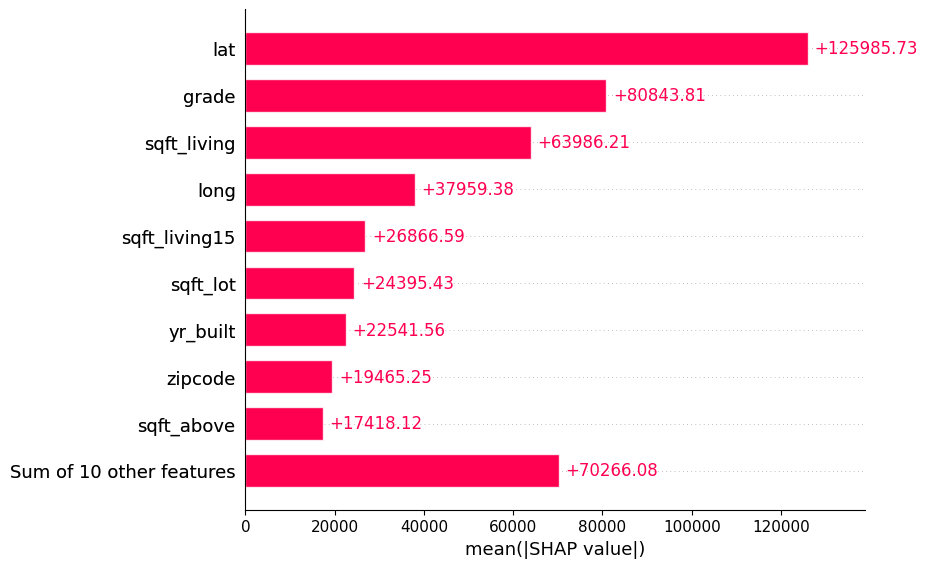

In [10]:
import shap

explainer = shap.Explainer(gb_with_img, X_train)

shap_values = explainer(X_test)

shap.initjs()
shap.plots.bar(shap_values, max_display=10)

Test Data